# Logistic curve fitting

The goal of this project is to evaluate fitting procedures to fit logistic curves with incomplete data. The problem is that when there only is data to the left of the inflection point, logistic fits tend to get extremly senitive to measurement errors.

In [4]:
# Initialize
library(tidyverse)
library(rstan)

# Run the chains in parallel on all available cores
options(mc.cores = parallel::detectCores())
# Cache the compiled Stan model to avoid recompilation of unchanged Stan programs
rstan_options(auto_write = TRUE)

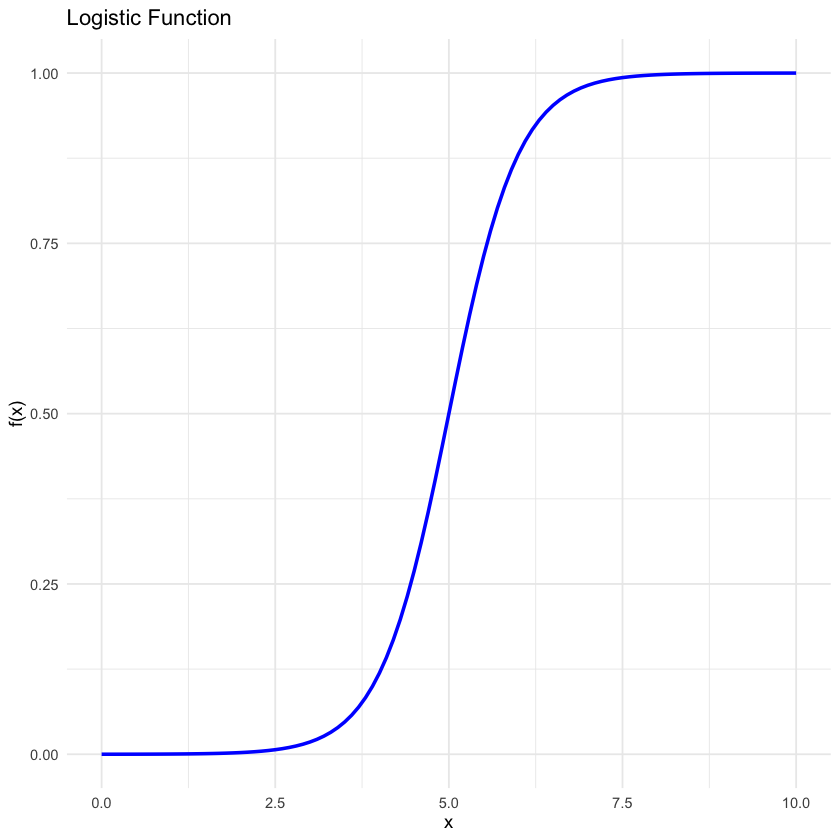

In [5]:
# Parameters for the logistic function
niveau <- 1
rate <- 2
inflection <- 5

x <- seq(0, 10, by = 0.1)
# Logistic function
logistic_function <- function(x, niveau, rate, inflection) {
  niveau / (1 + exp(-rate * (x - inflection)))
}

# Calculate the logistic function values
y <- logistic_function(x, niveau, rate, inflection)

# Create a data frame for plotting
tbl <- tibble(
    x = x,
    y = y
)

# Plot the logistic function
ggplot(tbl, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1) +
  labs(title = "Logistic Function",
       x = "x",
       y = "f(x)") +
  theme_minimal()

parameter,true,median,q05,q95,n_eff,Rhat
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
niveau,1,0.9690197,0.7790883,1.425223,704.4514,1.003097
inflection,5,4.9654992,4.7510379,5.334152,688.3852,1.003283
rate,2,2.0232693,1.7560293,2.301553,805.1481,1.002593


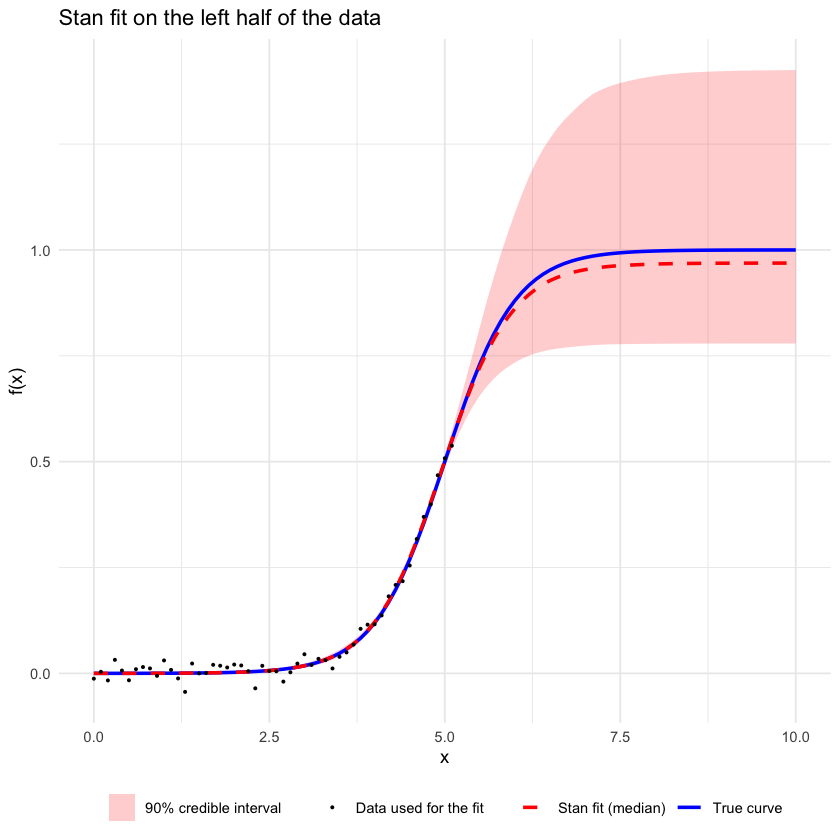

In [6]:
# Fit the logistic curve with Stan
set.seed(1)

# Add an error term and keep only the left half of the data for fitting
tbl <- tbl |>
  mutate(
    err = rnorm(nrow(tbl), mean = 0, sd = 0.02),
    y_obs = y + err
  )

tbl_half <- tbl |>
  slice_head(n = as.integer(nrow(tbl) * 0.52))

# Fit the logistic curve with Stan (model defined in logistic.stan)
fit <- stan(
    file = "logistic.stan",
    data = list(
        N = nrow(tbl_half),
        x = tbl_half$x,
        y = tbl_half$y_obs,
        N_pred = nrow(tbl),
        x_pred = tbl$x
    ),
    chains = 4,
    seed = 1,
    refresh = 0
)

# Compare the posterior of the parameters with the true values
pars <- c("niveau", "inflection", "rate")
summary(fit, pars = pars, probs = c(0.05, 0.5, 0.95))$summary |>
  as_tibble(rownames = "parameter") |>
  mutate(true = c(niveau, inflection, rate)) |>
  select(parameter, true, median = `50%`, q05 = `5%`, q95 = `95%`, n_eff, Rhat)

# Plot the true curve, the data used for the fit and the fitted curve with its 90% credible interval
pred <- summary(fit, pars = "mu_pred", probs = c(0.05, 0.5, 0.95))$summary

tbl |>
  # Add the posterior median and the 5% / 95% quantiles of the fitted curve as columns
  mutate(y_fit = pred[, "50%"], y_lower = pred[, "5%"], y_upper = pred[, "95%"]) |>
  # Start the plot; all layers share x as the horizontal axis
  ggplot(aes(x = x)) +
  # Shaded band between the 5% and 95% quantiles (fill is a label so it shows up in the legend)
  geom_ribbon(aes(ymin = y_lower, ymax = y_upper, fill = "90% credible interval"), alpha = 0.2) +
  # True logistic curve without noise
  geom_line(aes(y = y, color = "True curve", linetype = "True curve"), linewidth = 1) +
  # Posterior median of the fitted curve
  geom_line(
    aes(y = y_fit, color = "Stan fit (median)", linetype = "Stan fit (median)"),
    linewidth = 1
  ) +
  # Noisy observations the model was fitted to (only the left half)
  geom_point(data = tbl_half, aes(y = y_obs, shape = "Data used for the fit"), size = 0.8) +
  # Assign the line colors to the legend labels
  scale_color_manual(values = c("True curve" = "blue", "Stan fit (median)" = "red")) +
  # Assign the line types to the same labels, so color and line type share one legend entry
  scale_linetype_manual(values = c("True curve" = "solid", "Stan fit (median)" = "dashed")) +
  # Color of the credible interval band
  scale_fill_manual(values = c("90% credible interval" = "red")) +
  # Point shape of the data (16 = filled circle)
  scale_shape_manual(values = c("Data used for the fit" = 16)) +
  # Title and axis labels; NULL removes the titles above the legends
  labs(title = "Stan fit on the left half of the data",
       x = "x",
       y = "f(x)",
       color = NULL, linetype = NULL, fill = NULL, shape = NULL) +
  # Light theme without a grey background
  theme_minimal() +
  # Put the legend below the plot
  theme(legend.position = "bottom")